<a href="https://colab.research.google.com/github/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/blob/main/DIQ_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Data Profiling and Quality Assessment**

In [1]:
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 19.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.

In [2]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [3]:
# Importing libraries
import pandas as pd
import missingno as mno
from ydata_profiling import ProfileReport
from ydata_profiling.config import Settings
import numpy as np
import json

In [4]:
# Reading the dataset
artwork_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artwork_data.csv')
artist_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artist_data.csv')

/tmp/ipython-input-3758514550.py:2: DtypeWarning: Columns (9,13) have mixed types. Specify dtype option on import or set low_memory=False.
  artwork_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artwork_data.csv')


In [5]:
artwork_data

,id,accession_number,artist,artistRole,artistId,title,dateText,medium,creditLine,year,acquisitionYear,dimensions,width,height,depth,units,inscription,thumbnailCopyright,thumbnailUrl,url
0,1035,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,date not known,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,NaN,1922.0,support: 394 x 419 mm,394,419.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...
1,1036,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 311 x 213 mm,311,213.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...
2,1037,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,?c.1785,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,343,467.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
3,1038,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 318 x 394 mm,318,394.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...
4,1039,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,"1826–7, reprinted 1892",Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,243,335.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,122960,T13865,"P-Orridge, Genesis",artist,16646,Larvae (from Tampax Romana),1975,"Perspex, Wood, hairpiece, tampon and human blood",Transferred from Tate Archive 2012,1975,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/p-orridge-...
69197,122961,T13866,"P-Orridge, Genesis",artist,16646,Living Womb (from Tampax Romana),1976,"Wood, Perspex, plastic, photograph on paper, t...",Transferred from Tate Archive 2012,1976,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/p-orridge-...
69198,121181,T13867,"Hatoum, Mona",artist,2365,Present Tense,1996,Soap and glass beads,Presented by Tate Members 2013,1996,2013.0,displayed: 45 x 2410 x 2990 mm,45,2410.0,2990.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/hatoum-pre...
69199,112306,T13868,"Creed, Martin",artist,2760,Work No. 227: The lights going on and off,2000,Gallery lighting,"Purchased with funds provided by Tate Members,...",2000,2013.0,Overall display dimensions variable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/creed-work...


In [6]:
artist_data

,id,name,gender,dates,yearOfBirth,yearOfDeath,placeOfBirth,placeOfDeath,url
0,10093,"Abakanowicz, Magdalena",Female,born 1930,1930.0,NaN,Polska,NaN,http://www.tate.org.uk/art/artists/magdalena-a...
1,0,"Abbey, Edwin Austin",Male,1852–1911,1852.0,1911.0,"Philadelphia, United States","London, United Kingdom",http://www.tate.org.uk/art/artists/edwin-austi...
2,2756,"Abbott, Berenice",Female,1898–1991,1898.0,1991.0,"Springfield, United States","Monson, United States",http://www.tate.org.uk/art/artists/berenice-ab...
3,1,"Abbott, Lemuel Francis",Male,1760–1803,1760.0,1803.0,"Leicestershire, United Kingdom","London, United Kingdom",http://www.tate.org.uk/art/artists/lemuel-fran...
4,622,"Abrahams, Ivor",Male,born 1935,1935.0,NaN,"Wigan, United Kingdom",NaN,http://www.tate.org.uk/art/artists/ivor-abraha...
...,...,...,...,...,...,...,...,...,...
3527,12542,"Zorio, Gilberto",Male,born 1944,1944.0,NaN,"Andorno Micca, Italia",NaN,http://www.tate.org.uk/art/artists/gilberto-zo...
3528,2186,"Zox, Larry",Male,born 1936,1936.0,NaN,"Des Moines, United States",NaN,http://www.tate.org.uk/art/artists/larry-zox-2186
3529,621,"Zuccarelli, Francesco",Male,1702–1788,1702.0,1788.0,Italia,Firenze,http://www.tate.org.uk/art/artists/francesco-z...
3530,2187,"Zuloaga, Ignacio",Male,1870–1945,1870.0,1945.0,España,España,http://www.tate.org.uk/art/artists/ignacio-zul...


In [7]:
# --- DIRTY DATA BASELINE MODEL ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("--- ESTABLISHING BASELINE PERFORMANCE (DIRTY DATA) ---")

# 1. Define temporary target logic (just for this baseline test)
def clean_medium_dirty(text):
    text = str(text).lower()
    if any(x in text for x in ['video', 'film', 'audio', 'digital', 'screenprint', 'photograph', 'installation']): return 'Modern Media'
    if any(x in text for x in ['bronze', 'marble', 'stone', 'plaster', 'sculpture', 'metal', 'wood']): return 'Sculpture'
    if any(x in text for x in ['oil', 'canvas', 'tempera', 'panel', 'paint', 'gouache']): return 'Painting'
    if any(x in text for x in ['paper', 'ink', 'graphite', 'watercolour', 'chalk', 'pencil', 'print', 'etching']): return 'Work on Paper'
    return 'Other'

# 2. Prepare Dirty Features
dirty_data = artwork_data.copy()
dirty_data['medium_group_target'] = dirty_data['medium'].apply(clean_medium_dirty)

# Select raw features (using original column names from the start of the notebook)
dirty_features = dirty_data[['year', 'acquisitionYear', 'width', 'height']].copy()

# 3. Naive Pre-processing
for col in dirty_features.columns:
    dirty_features[col] = pd.to_numeric(dirty_features[col], errors='coerce').fillna(0)

X_dirty = dirty_features
y_dirty = dirty_data['medium_group_target']

# 4. Train Baseline Model
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dirty, y_dirty, test_size=0.3, random_state=42)

clf_dirty = RandomForestClassifier(n_estimators=100, random_state=42)
clf_dirty.fit(X_train_d, y_train_d)

# 5. Calculate Metrics
y_pred_d = clf_dirty.predict(X_test_d)

# Calculate Accuracy
dirty_acc = accuracy_score(y_test_d, y_pred_d)
# Calculate Precision, Recall, F1 (Weighted average for multi-class)
dirty_prec, dirty_rec, dirty_f1, _ = precision_recall_fscore_support(y_test_d, y_pred_d, average='weighted', zero_division=0)

print(f"DIRTY Data Performance:")
print(f"Accuracy:  {dirty_acc:.2%}")
print(f"Precision: {dirty_prec:.2%}")
print(f"Recall:    {dirty_rec:.2%}")
print(f"F1 Score:  {dirty_f1:.2%}")

--- ESTABLISHING BASELINE PERFORMANCE (DIRTY DATA) ---
DIRTY Data Performance:
Accuracy:  86.50%
Precision: 86.10%
Recall:    86.50%
F1 Score:  86.02%


In [8]:
config=Settings()
config.vars.text.words = False

profile = ProfileReport(artwork_data, title = "ARTWORKS_REPORT", config = config)

In [9]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:06<00:00,  3.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Printing the dimesnsions of the data
print('dimensions of artwork data:', artwork_data.shape)
print('dimensions of artist data:', artist_data.shape)

dimensions of artwork data: (69201, 20)
dimensions of artist data: (3532, 9)


In [11]:
# Showing the type of columns
artwork_data.dtypes

,0
id,int64
accession_number,object
artist,object
artistRole,object
artistId,int64
title,object
dateText,object
medium,object
creditLine,object
year,object


In [12]:
# Checking for duplicates
artwork_data.duplicated().any()

np.False_

In [13]:
# Checking null values
artwork_data.isnull()

,id,accession_number,artist,artistRole,artistId,title,dateText,medium,creditLine,year,acquisitionYear,dimensions,width,height,depth,units,inscription,thumbnailCopyright,thumbnailUrl,url
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69199,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,False


In [14]:
# Check the number of null values in each column
artwork_data.isnull().sum()

,0
id,0
accession_number,0
artist,0
artistRole,0
artistId,0
title,0
dateText,0
medium,6384
creditLine,3
year,5378


In [15]:
# Number of nit Null values in each column
artwork_data.notnull().sum()

,0
id,69201
accession_number,69201
artist,69201
artistRole,69201
artistId,69201
title,69201
dateText,69201
medium,62817
creditLine,69198
year,63823


In [16]:
# Total number of Nulls in the data
artwork_data.isnull().sum().sum()

np.int64(219596)

In [17]:
# Total number of cells that are not Null
Not_Null = artwork_data.notnull().sum().sum()
Not_Null

np.int64(1164424)

In [18]:
# Total number of cells in the data
TOT = artwork_data.shape[0]*artwork_data.shape[1]
TOT

1384020

<Axes: >

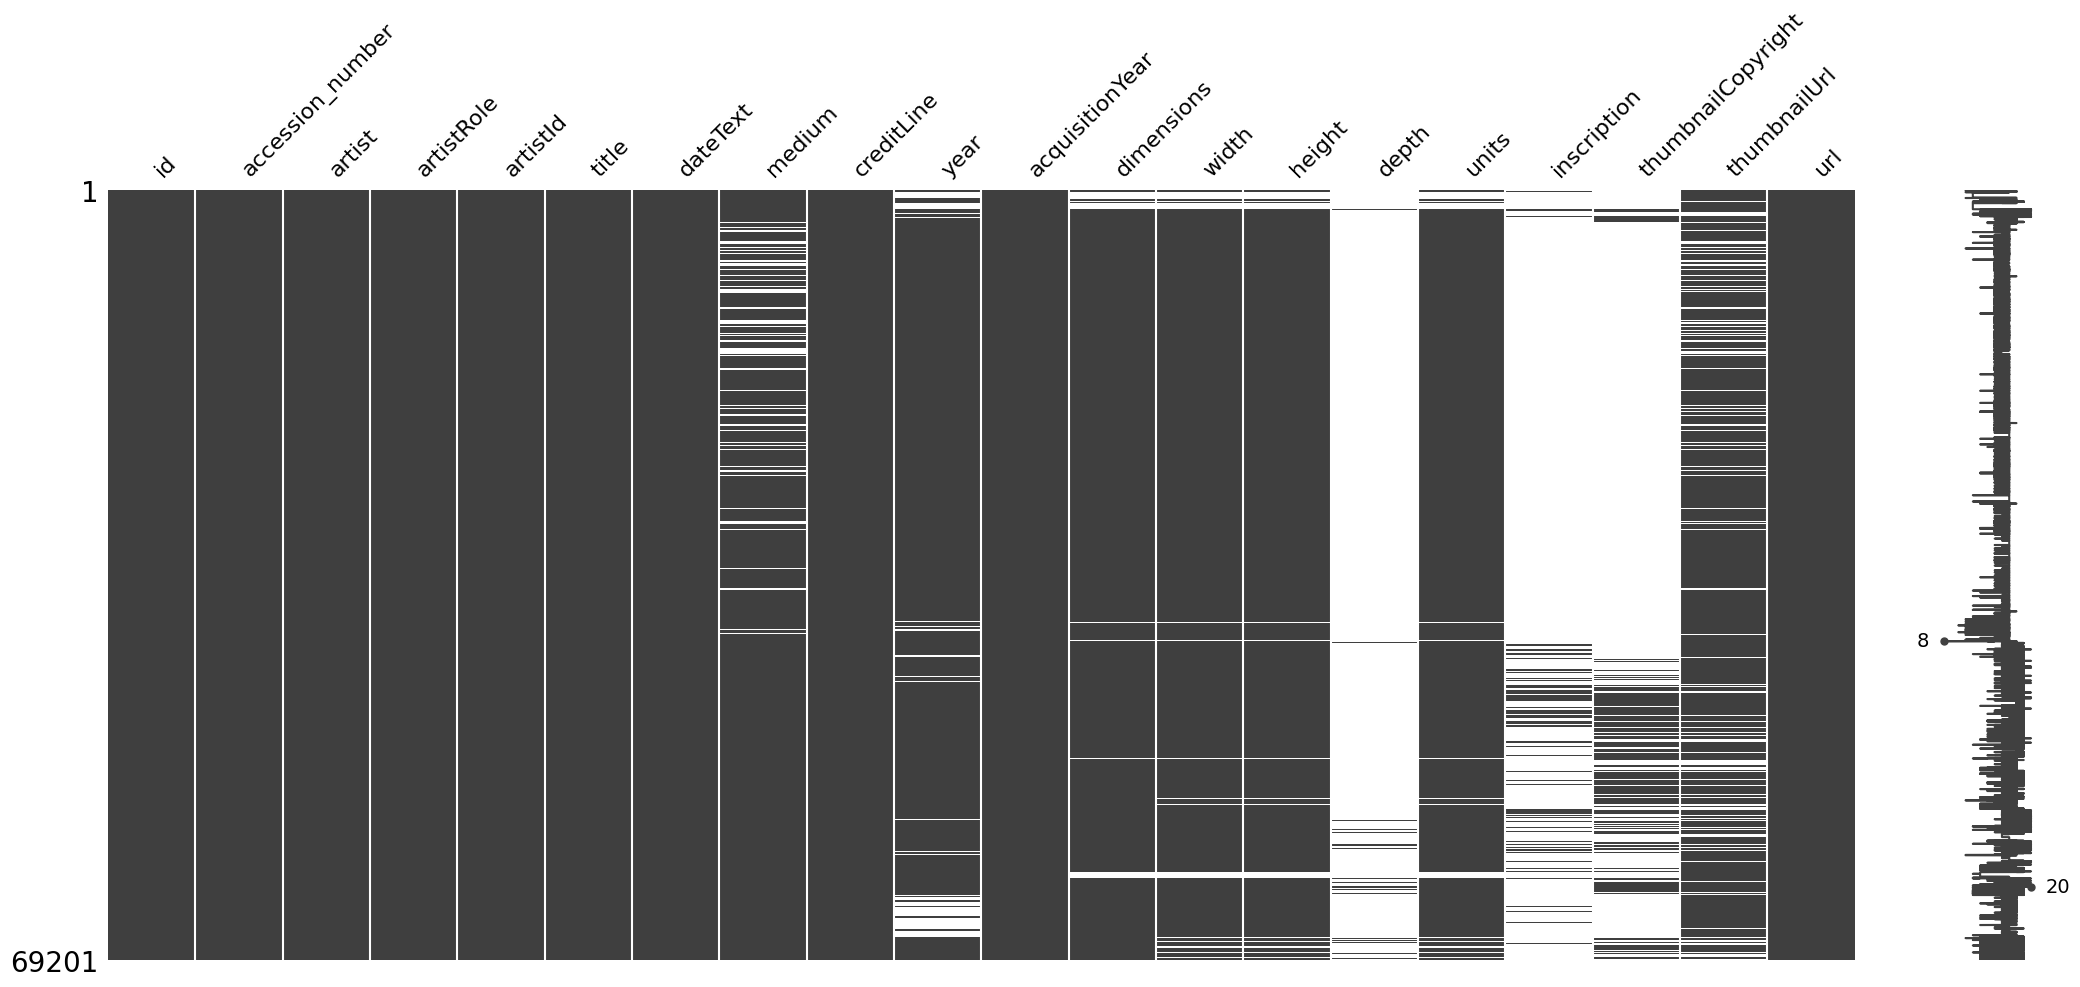

In [19]:
mno.matrix(artwork_data)

In [20]:
# Evaluating Completeness
Completeness = Not_Null/TOT
Completeness = '{0:.1f}%'.format(Completeness*100)
print(Completeness)

84.1%


# **2. Data Transformation & Standardization**

In [21]:
# Getting information about each column
artwork_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69201 entries, 0 to 69200
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  69201 non-null  int64  
 1   accession_number    69201 non-null  object 
 2   artist              69201 non-null  object 
 3   artistRole          69201 non-null  object 
 4   artistId            69201 non-null  int64  
 5   title               69201 non-null  object 
 6   dateText            69201 non-null  object 
 7   medium              62817 non-null  object 
 8   creditLine          69198 non-null  object 
 9   year                63823 non-null  object 
 10  acquisitionYear     69156 non-null  float64
 11  dimensions          66768 non-null  object 
 12  width               65860 non-null  object 
 13  height              65860 non-null  object 
 14  depth               2514 non-null   float64
 15  units               65860 non-null  object 
 16  insc

In [22]:
# Dropping redundant columns
artwork_data = artwork_data.drop(['id', 'dateText'], axis =1)

In [23]:
# Renaming columns
artwork_data = artwork_data.rename(columns = {'accession_number':'Accession Number','artist': 'Artist','artistRole':'Artist Role','artistId':'Artist ID', 'title': 'Title', 'medium': 'Medium', 'creditLine': 'Credit Line', 'year': 'Year', 'acquisitionYear': 'Acquisition Year', 'dimensions': 'Dimensions', 'width':'Width', 'height':'Height', 'depth':'Depth', 'units':'Units','inscription': 'Inscription' ,'thumbnailCopyright': 'Thumbnail Copyright', 'thumbnailUrl': 'Thumbnail URL', 'url': 'URL'})

In [24]:
# Data Standardization
untitled_variants = [
    '[title not known]',
    'Blank',
    '[blank]',
    '[no title]'
]
artwork_data['Title'] = artwork_data['Title'].replace(untitled_variants,'Title Not Known')
artwork_data['Year'] = artwork_data['Year'].replace('no date','Date Not Known')
artwork_data['Year'] = artwork_data['Year'].replace('c.1997-9', '1997-9')
artwork_data['Artist'] = artwork_data['Artist'].str.replace(r'^\?', '', regex=True)
mask_inscription = artwork_data['Title'].str.contains(r'inscription', case=False, regex=True)
artwork_data.loc[mask_inscription, 'Title'] = 'Inscription (Various)'


In [25]:
# Check for inconsistencies between names and id pairs in artworks and artist dataset
official_names = artist_data.set_index('id')['name']
mask_mismatch = (
    artwork_data['Artist ID'].isin(official_names.index) &
    (artwork_data['Artist'].str.strip() != artwork_data['Artist ID'].map(official_names).str.strip())
)

mismatches = artwork_data[mask_mismatch]
mismatches

,Accession Number,Artist,Artist Role,Artist ID,Title,Medium,Credit Line,Year,Acquisition Year,Dimensions,Width,Height,Depth,Units,Inscription,Thumbnail Copyright,Thumbnail URL,URL


In [26]:
# Lets group the different mediums into larger groups
def clean_medium(text):
    # Convert to string and lowercase to avoid case issues
    text = str(text).lower()

    # Modern/New Media
    if any(x in text for x in ['video', 'film', 'audio', 'digital', 'screenprint', 'photograph', 'c-print', 'plastic', 'acrylic', 'installation']):
        return 'Modern Media'

    # Sculptures (3D Materials)
    if any(x in text for x in ['bronze', 'marble', 'stone', 'plaster', 'sculpture', 'metal', 'steel', 'wood', 'glass']):
        return 'Sculpture'

    # Paintings (Traditional)
    if any(x in text for x in ['oil', 'canvas', 'tempera', 'panel', 'paint', 'gouache']):
        return 'Painting'

    # Works on Paper (Drawings, Prints)
    if any(x in text for x in ['paper', 'ink', 'graphite', 'watercolour', 'chalk', 'pencil', 'print', 'etching', 'engraving', 'lithograph']):
        return 'Work on Paper'

    # Everything else
    return 'Other/Unknown'

artwork_data['Medium Group'] = artwork_data['Medium'].apply(clean_medium)


# Compare the mess of the original vs the clean version
print("--- Before (Top 5 Raw) ---")
print(artwork_data['Medium'].value_counts().head(5))

print("\n--- After (Clean Categories) ---")
print(artwork_data['Medium Group'].value_counts())

--- Before (Top 5 Raw) ---
Medium
Graphite on paper       26167
Oil paint on canvas      3383
Screenprint on paper     2984
Lithograph on paper      2721
Watercolour on paper     1890
Name: count, dtype: int64

--- After (Clean Categories) ---
Medium Group
Work on Paper    46438
Other/Unknown     7072
Painting          6603
Modern Media      6510
Sculpture         2578
Name: count, dtype: int64


In [27]:
import re

def parse_dimensions_from_string(dim_str):
    if pd.isna(dim_str) or str(dim_str).strip().lower() == 'not mentioned' or str(dim_str).strip() == '':
        return pd.Series(['Not Mentioned', 'Not Mentioned', 'Not Mentioned', 'Not Mentioned'], index=['Width', 'Height', 'Depth', 'Units'])

    dim_str_clean = str(dim_str).strip().lower()

    units = ''
    # Check for and extract 'mm' unit
    if 'mm' in dim_str_clean:
        units = 'mm'
        # Remove 'mm' and any surrounding characters that are not digits or 'x' to simplify splitting
        dim_str_clean = re.sub(r'\s*mm.*', '', dim_str_clean).strip()
    elif 'ft' in dim_str_clean:
        units = 'ft'

    # Extract all numbers that are part of the dimensions
    numbers = re.findall(r'\d+\.?\d*', dim_str_clean)

    width = numbers[0] if len(numbers) > 0 else ''
    height = numbers[1] if len(numbers) > 1 else ''
    depth = numbers[2] if len(numbers) > 2 else ''

    return pd.Series([width, height, depth, units], index=['Width', 'Height', 'Depth', 'Units'])

# Standardize dimension format: replace ' mmx ' with 'x'
artwork_data['Dimensions'] = artwork_data['Dimensions'].astype(str).str.replace(r'\s*mm x\s*', ' x ', regex=True)

# Identify rows where Width or Height are empty/NaN AND Dimensions is not 'Not Mentioned'
mask_to_update = \
    ((artwork_data['Width'].isna()) | (artwork_data['Width'] == '')) & \
    ((artwork_data['Height'].isna()) | (artwork_data['Height'] == '')) & \
    (artwork_data['Dimensions'] != 'Not Mentioned')

# Apply the function to the 'Dimensions' column for the masked rows
extracted_data = artwork_data.loc[mask_to_update, 'Dimensions'].apply(parse_dimensions_from_string)

# Update the original DataFrame with the extracted data
artwork_data.loc[mask_to_update, ['Width', 'Height', 'Depth', 'Units']] = extracted_data

print("Dimensions extracted from 'Dimensions' column and updated 'Width', 'Height', 'Depth', 'Units' where applicable.")
artwork_data.head()

/tmp/ipython-input-684892632.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['' '' '' ... '' '' '']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  artwork_data.loc[mask_to_update, ['Width', 'Height', 'Depth', 'Units']] = extracted_data


Dimensions extracted from 'Dimensions' column and updated 'Width', 'Height', 'Depth', 'Units' where applicable.


,Accession Number,Artist,Artist Role,Artist ID,Title,Medium,Credit Line,Year,Acquisition Year,Dimensions,Width,Height,Depth,Units,Inscription,Thumbnail Copyright,Thumbnail URL,URL,Medium Group
0,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,NaN,1922.0,support: 394 x 419 mm,394,419.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...,Work on Paper
1,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 311 x 213 mm,311,213.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...,Work on Paper
2,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,343,467.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...,Work on Paper
3,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 318 x 394 mm,318,394.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...,Work on Paper
4,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,243,335.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...,Work on Paper


In [28]:
# We want to fill empty cells of 'year' with an approximation, while also representing the uncertainty in a separate variable

print("Artist Columns:", artist_data.columns.tolist())

# Select the correct columns (renaming them to be consistent with our logic)
artist_dates = artist_data[['id', 'yearOfBirth', 'yearOfDeath']].rename(
    columns={'yearOfBirth': 'birthYear', 'yearOfDeath': 'deathYear'}
)

# Merge them into the main dataframe
artwork_data = artwork_data.reset_index().merge(
    artist_dates,
    left_on='Artist ID',
    right_on='id',
    how='left',
    suffixes=('', '_artist_numeric')
)

artwork_data = artwork_data.drop(columns=['id_artist_numeric'], errors='ignore')

# Define approximation logic
def estimate_year_logic(row):
    # Convert 'Year' to numeric, coercing errors to NaN
    year_val = pd.to_numeric(row['Year'], errors='coerce')

    # Case A: We already have a valid year (numeric) -> "Verified"
    if pd.notna(year_val):
        return pd.Series([year_val, "Verified", f"{int(year_val)}"])

    # Case B: Missing year, but we have Artist Birth/Death
    if pd.notna(row['birthYear']) and pd.notna(row['deathYear']):
        # Assumption: Artist starts working at age 20
        start_career = row['birthYear'] + 20
        end_career = row['deathYear']

        # Check validity (sometimes death is missing or invalid)
        if end_career > start_career:
            mid_point = start_career + (end_career - start_career) / 2
            label = f"c. {int(start_career)}–{int(end_career)} (Artist Era)"
            return pd.Series([int(mid_point), "Estimated", label])

    # Case C: No data at all -> Remain Missing
    return pd.Series([np.nan, "Unknown", "Date not known"])

print("Calculating estimates for missing years...")
artwork_data[['year_numeric', 'Year Certainty', 'date_display']] = artwork_data.apply(estimate_year_logic, axis=1)

estimated_mask = artwork_data['Year Certainty'] == 'Estimated'

# Identify rows where 'Year' is 'Date Not Known' or is NaN (after numeric conversion)
mask_update_year = (artwork_data['Year'] == 'Date Not Known') | (pd.isna(pd.to_numeric(artwork_data['Year'], errors='coerce')))

# Fill 'Year' with 'year_numeric' for the identified rows. Convert 'year_numeric' to int before assignment.
artwork_data.loc[mask_update_year, 'Year'] = artwork_data.loc[mask_update_year, 'year_numeric'].fillna(artwork_data.loc[mask_update_year, 'Year']).astype(object)

print("Updated 'Year' column with 'year_numeric' where original 'Year' was 'Date Not Known' or missing.")

print(artwork_data[estimated_mask][['Artist','year_numeric', 'Year Certainty', 'date_display']].sample(10))

cols_to_drop = ['index','id', 'birthYear', 'deathYear', 'date_display', 'year_numeric']

artwork_data = artwork_data.drop(columns=cols_to_drop, errors='ignore')



Artist Columns: ['id', 'name', 'gender', 'dates', 'yearOfBirth', 'yearOfDeath', 'placeOfBirth', 'placeOfDeath', 'url']
Calculating estimates for missing years...
Updated 'Year' column with 'year_numeric' where original 'Year' was 'Date Not Known' or missing.
                               Artist  year_numeric Year Certainty  \
66015            Davis, John Scarlett        1834.0      Estimated   
65742                 Martin, Charles        1869.0      Estimated   
64041       Martin, J., of Canterbury        1859.0      Estimated   
63426               Cozens, Alexander        1761.0      Estimated   
66865               Cotman, John Sell        1822.0      Estimated   
61457  Turner, Joseph Mallord William        1823.0      Estimated   
59663                Highmore, Joseph        1746.0      Estimated   
65689     British School 18th century        1759.0      Estimated   
40600            Dupont, Gainsborough        1785.0      Estimated   
59720               Duncombe, Susanna    

# **3. Error Detection and Correction**

In [29]:
import numpy as np

# Define the list of problematic strings to remove from 'Width'
problematic_width_strings = [
    '(upper):', '(left):', '(top):', '(each):', 'each', '(1):', 'ea.316',
    '(image):', '(diameter):', '(overall):'
]

# Create a mask to identify rows where 'Width' contains any of the problematic strings
mask_problematic_width = artwork_data['Width'].astype(str).isin(problematic_width_strings)

if mask_problematic_width.any():
    # For these rows, set Width, Height, Depth, and Units to 'Not Mentioned'
    # This allows the subsequent re-parsing logic to take over.
    artwork_data.loc[mask_problematic_width, ['Width', 'Height', 'Depth', 'Units']] = 'Not Mentioned'

    # Re-apply the parse_dimensions_from_string function for these specific rows
    # The function 'parse_dimensions_from_string' is assumed to be defined in a previous cell.
    re_extracted_data = artwork_data.loc[mask_problematic_width, 'Dimensions'].apply(parse_dimensions_from_string)

    # Update the original DataFrame with the newly extracted data
    artwork_data.loc[mask_problematic_width, ['Width', 'Height', 'Depth', 'Units']] = re_extracted_data

In [30]:
artwork_data['Height'] = artwork_data['Height'].astype(str)
artwork_data['Depth'] = artwork_data['Depth'].astype(str)

# Find rows where 'Height' is exactly 'mm'
mask_mm_in_height = (artwork_data['Height'] == 'mm')

# If there are any rows where 'Height' is 'mm', perform the replacement
if mask_mm_in_height.any():
    artwork_data.loc[mask_mm_in_height, 'Height'] = artwork_data.loc[mask_mm_in_height, 'Depth']
    artwork_data.loc[mask_mm_in_height, 'Depth'] = 'Not Mentioned'

In [31]:
# Identify rows where 'Dimensions' is blank
missing_dimensions_mask = artwork_data['Dimensions'].isna() | (artwork_data['Dimensions'] == '')

# Fill corresponding 'Width', 'Height', 'Depth', and 'Units' with 'Not Mentioned'
artwork_data.loc[missing_dimensions_mask, ['Dimensions', 'Width', 'Height', 'Depth', 'Units']] = 'Not Mentioned'

In [32]:
# Filling empty cells and string 'nan' values
artwork_data['Medium'] = artwork_data['Medium'].fillna('Not Mentioned')
artwork_data['Credit Line'] = artwork_data['Credit Line'].fillna('None')
artwork_data['Thumbnail Copyright'] = artwork_data['Thumbnail Copyright'].fillna('None')
artwork_data['Thumbnail URL'] = artwork_data['Thumbnail URL'].fillna('None')
artwork_data['Acquisition Year'] = artwork_data['Acquisition Year'].fillna('Date Not Known')
artwork_data['Year'] = artwork_data['Year'].fillna('Date Not Known')
artwork_data['Inscription'] = artwork_data['Inscription'].fillna('None')

# For columns that might contain the string 'nan' due to prior type conversion
for col in ['Height', 'Depth', 'Width', 'Units', 'Dimensions']:
    artwork_data[col] = artwork_data[col].replace('nan', 'Not Mentioned').replace('', 'Not Mentioned').fillna('Not Mentioned')

<Axes: >

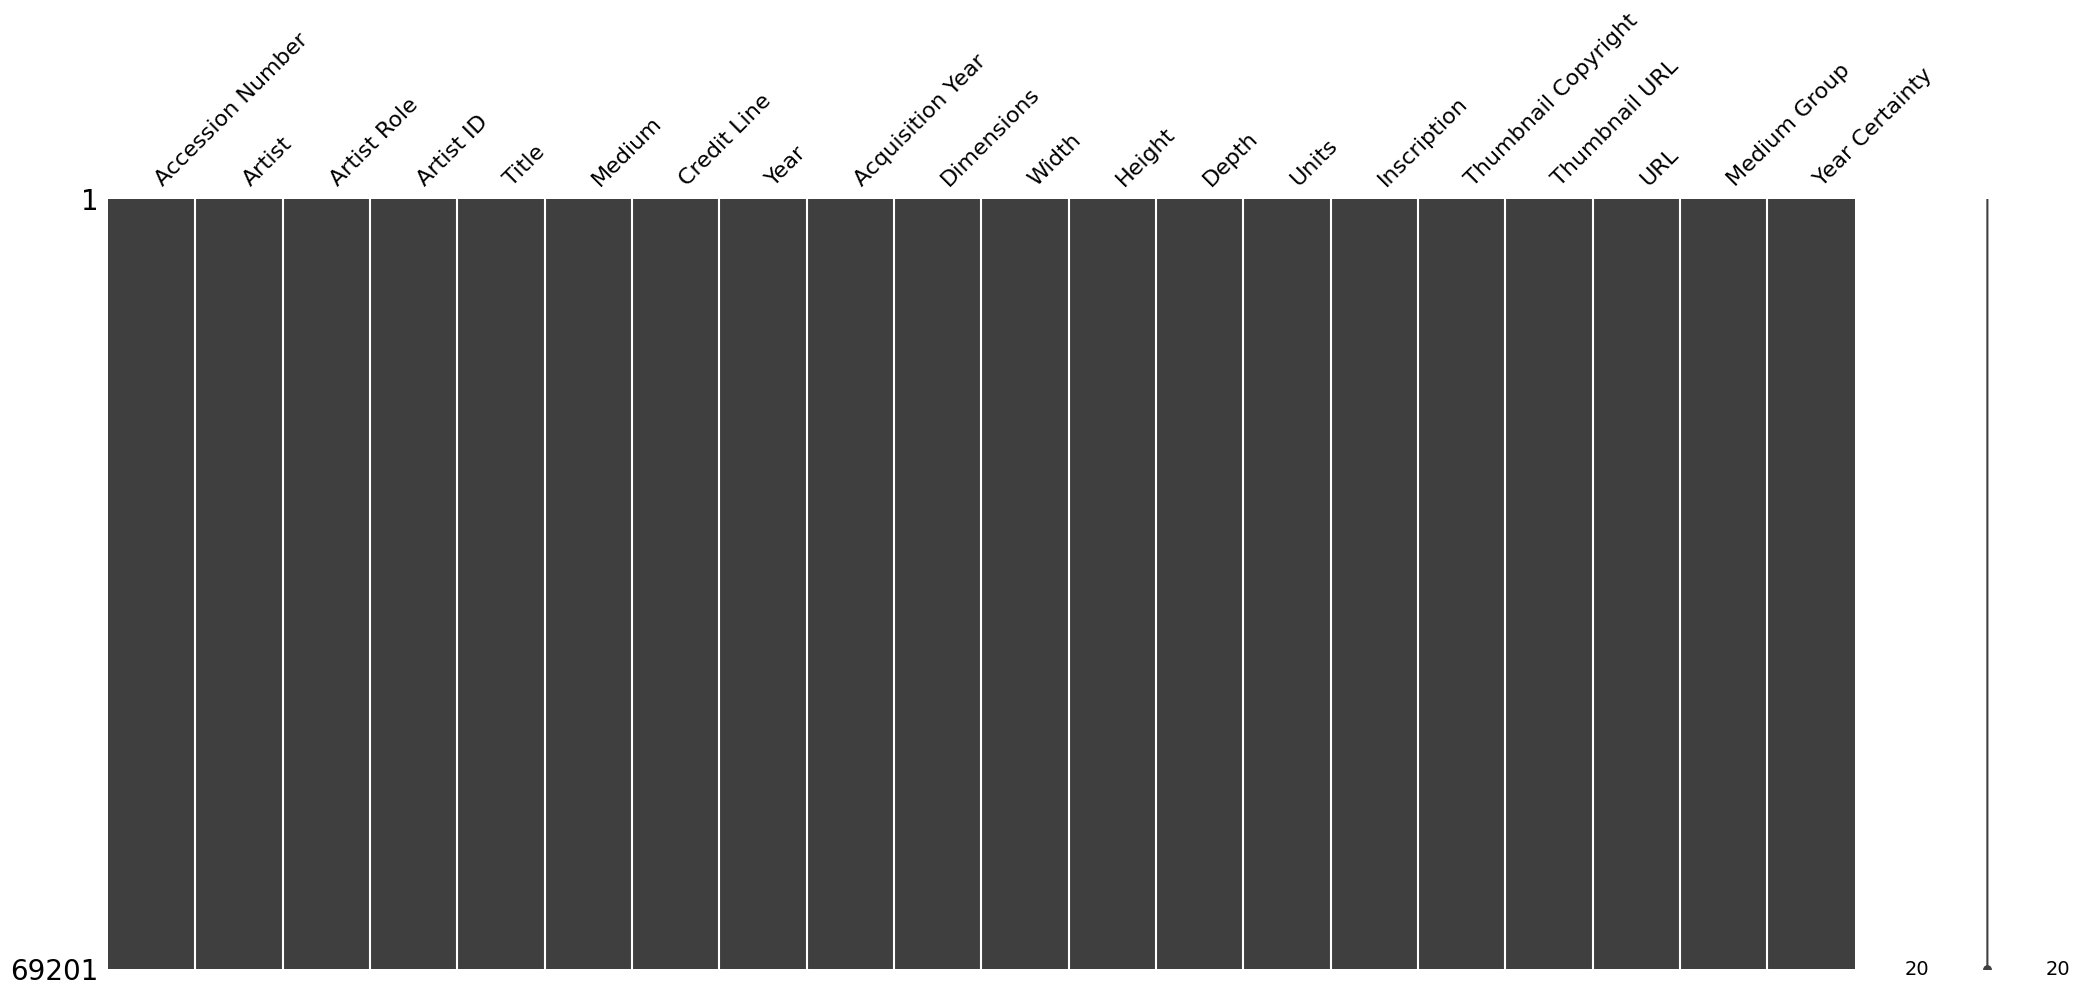

In [33]:
mno.matrix(artwork_data)

In [34]:
# Exporting dataframe into a .csv file
artwork_data.to_csv('artwork_data_cleaned.csv', index = False, encoding = 'utf_8_sig')

# **4. Data Deduplication and Similarity Detection**

In [35]:
!pip install recordlinkage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 27.7 MB/s eta 0:00:00


In [36]:
import recordlinkage
from recordlinkage import Index, Compare

In [37]:
indexer = recordlinkage.Index()
indexer.block(['Artist ID', 'Artist', 'Title'])
candidate_links = indexer.index(artwork_data)
print(f"Generated {len(candidate_links)} candidate links using blocking on 'Artist ID', 'Artist' and 'Title'.")
candidate_links

Generated 21386989 candidate links using blocking on 'Artist ID', 'Artist' and 'Title'.


MultiIndex([(   38,    37),
            (   51,    50),
            (   52,    50),
            (   52,    51),
            (   53,    50),
            (   53,    51),
            (   53,    52),
            (   54,    50),
            (   54,    51),
            (   54,    52),
            ...
            (69173, 69163),
            (69173, 69164),
            (69173, 69165),
            (69173, 69166),
            (69173, 69167),
            (69173, 69168),
            (69173, 69169),
            (69173, 69170),
            (69173, 69171),
            (69173, 69172)],
           length=21386989)

In [38]:
#Compare records
comparator = recordlinkage.Compare()
comparator.exact('Accession Number', 'Accession Number',label='Accession Number')
comparator.exact('URL', 'URL',label='URL')
comparator.string('Title', 'Title', threshold=  0.85,label='Title')

<Compare>

In [39]:
compare_vectors = comparator.compute(candidate_links, artwork_data)
compare_vectors

Accession Number  URL  Title
38    37                    0    0    1.0
51    50                    0    0    1.0
52    50                    0    0    1.0
      51                    0    0    1.0
53    50                    0    0    1.0
...                       ...  ...    ...
69173 69168                 0    0    1.0
      69169                 0    0    1.0
      69170                 0    0    1.0
      69171                 0    0    1.0
      69172                 0    0    1.0

[21386989 rows x 3 columns]

In [40]:
compare_vectors.describe()

,Accession Number,URL,Title
count,21386989.0,21386989.0,21386989.0
mean,0.0,0.0,1.0
std,0.0,0.0,0.0
min,0.0,0.0,1.0
25%,0.0,0.0,1.0
50%,0.0,0.0,1.0
75%,0.0,0.0,1.0
max,0.0,0.0,1.0


In [41]:
scores = compare_vectors.sum(axis=1)
scores.describe()

,0
count,21386989.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [42]:
threshold = 0.85
matches = scores[scores >= threshold]
matches

38     37       1.0
51     50       1.0
52     50       1.0
       51       1.0
53     50       1.0
               ... 
69173  69168    1.0
       69169    1.0
       69170    1.0
       69171    1.0
       69172    1.0
Length: 21386989, dtype: float64

In [43]:
profile_clean = ProfileReport(artwork_data, title = "ARTWORKS_REPORT_CLEAN", config = config)

In [44]:
profile_clean

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:05<00:00,  3.36it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **5. Final Data Quality Assesment**

In [45]:
artwork_data

,Accession Number,Artist,Artist Role,Artist ID,Title,Medium,Credit Line,Year,Acquisition Year,Dimensions,Width,Height,Depth,Units,Inscription,Thumbnail Copyright,Thumbnail URL,URL,Medium Group,Year Certainty
0,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,1784.0,1922.0,support: 394 x 419 mm,394,419.0,Not Mentioned,mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...,Work on Paper,Estimated
1,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",Graphite on paper,Presented by Mrs John Richmond 1922,1784.0,1922.0,support: 311 x 213 mm,311,213.0,Not Mentioned,mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...,Work on Paper,Estimated
2,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,343,467.0,Not Mentioned,mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...,Work on Paper,Verified
3,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,Graphite on paper,Presented by Mrs John Richmond 1922,1784.0,1922.0,support: 318 x 394 mm,318,394.0,Not Mentioned,mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...,Work on Paper,Estimated
4,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,243,335.0,Not Mentioned,mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...,Work on Paper,Verified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,T13865,"P-Orridge, Genesis",artist,16646,Larvae (from Tampax Romana),"Perspex, Wood, hairpiece, tampon and human blood",Transferred from Tate Archive 2012,1975,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,None,None,None,http://www.tate.org.uk/art/artworks/p-orridge-...,Sculpture,Verified
69197,T13866,"P-Orridge, Genesis",artist,16646,Living Womb (from Tampax Romana),"Wood, Perspex, plastic, photograph on paper, t...",Transferred from Tate Archive 2012,1976,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,None,None,None,http://www.tate.org.uk/art/artworks/p-orridge-...,Modern Media,Verified
69198,T13867,"Hatoum, Mona",artist,2365,Present Tense,Soap and glass beads,Presented by Tate Members 2013,1996,2013.0,displayed: 45 x 2410 x 2990 mm,45,2410.0,2990.0,mm,None,None,None,http://www.tate.org.uk/art/artworks/hatoum-pre...,Sculpture,Verified
69199,T13868,"Creed, Martin",artist,2760,Work No. 227: The lights going on and off,Gallery lighting,"Purchased with funds provided by Tate Members,...",2000,2013.0,Overall display dimensions variable,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,None,None,None,http://www.tate.org.uk/art/artworks/creed-work...,Other/Unknown,Verified


In [46]:
# Printing the dimesnsions of the data
print('dimensions of artwork data:', artwork_data.shape)

dimensions of artwork data: (69201, 20)


In [47]:
# Showing the type of columns
artwork_data.dtypes

,0
Accession Number,object
Artist,object
Artist Role,object
Artist ID,int64
Title,object
Medium,object
Credit Line,object
Year,object
Acquisition Year,object
Dimensions,object


In [48]:
# Checking for duplicates
artwork_data.duplicated().any()

np.False_

In [49]:
# Checking null values
artwork_data.isnull()

,Accession Number,Artist,Artist Role,Artist ID,Title,Medium,Credit Line,Year,Acquisition Year,Dimensions,Width,Height,Depth,Units,Inscription,Thumbnail Copyright,Thumbnail URL,URL,Medium Group,Year Certainty
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69199,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [50]:
# Check the number of null values in each column
artwork_data.isnull().sum()

,0
Accession Number,0
Artist,0
Artist Role,0
Artist ID,0
Title,0
Medium,0
Credit Line,0
Year,0
Acquisition Year,0
Dimensions,0


In [51]:
# Number of nit Null values in each column
artwork_data.notnull().sum()

,0
Accession Number,69201
Artist,69201
Artist Role,69201
Artist ID,69201
Title,69201
Medium,69201
Credit Line,69201
Year,69201
Acquisition Year,69201
Dimensions,69201


In [52]:
# Total number of Nulls in the data
artwork_data.isnull().sum().sum()

np.int64(0)

In [53]:
# Total number of cells that are not Null
Not_Null = artwork_data.notnull().sum().sum()
Not_Null

np.int64(1384020)

In [54]:
# Total number of cells in the data
TOT = artwork_data.shape[0]*artwork_data.shape[1]
TOT

1384020

In [55]:
# Evaluating Completeness
Completeness = Not_Null/TOT
Completeness = '{0:.1f}%'.format(Completeness*100)
print(Completeness)

100.0%


# **6. Downstream Analysis & Impact Assessment**

In [56]:
# --- CLEAN DATA ANALYSIS ---
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EVALUATING CLEAN DATA PERFORMANCE ---")

# 1. Drop Useless Columns (As requested, right before analysis)
# We remove identifiers, URLs, copyright info, and raw text that isn't useful for the model
cols_to_drop = [
    'Accession Number', 'Artist', 'Artist Role', 'Artist ID', 'Title',
    'Medium', 'Credit Line', 'Dimensions', 'Units', 'Inscription',
    'Thumbnail Copyright', 'Thumbnail URL', 'URL', 'Year Certainty'
]

# Create a temporary dataframe for analysis by dropping these columns
# We use errors='ignore' in case some columns were already removed or renamed
model_data = artwork_data.drop(columns=cols_to_drop, errors='ignore').copy()

print(f"Columns remaining for analysis: {model_data.columns.tolist()}")

# 2. Feature Engineering on Cleaned Data
# Ensure numeric types for the model
model_data['Year_Numeric'] = pd.to_numeric(model_data['Year'], errors='coerce').fillna(0)
model_data['Acq_Year_Numeric'] = pd.to_numeric(model_data['Acquisition Year'], errors='coerce').fillna(0)
model_data['Width_Numeric'] = pd.to_numeric(model_data['Width'], errors='coerce').fillna(0)
model_data['Height_Numeric'] = pd.to_numeric(model_data['Height'], errors='coerce').fillna(0)

# 3. Select Features and Target
features = ['Year_Numeric', 'Acq_Year_Numeric', 'Height_Numeric', 'Width_Numeric']
target = 'Medium Group'

X_clean = model_data[features]
y_clean = model_data[target]

# 4. Train Model
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

clf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
clf_clean.fit(X_train_c, y_train_c)

# 5. Calculate Metrics
y_pred_c = clf_clean.predict(X_test_c)

clean_acc = accuracy_score(y_test_c, y_pred_c)
clean_prec, clean_rec, clean_f1, _ = precision_recall_fscore_support(y_test_c, y_pred_c, average='weighted', zero_division=0)

print(f"CLEAN Data Performance:")
print(f"Accuracy:  {clean_acc:.2%}")
print(f"Precision: {clean_prec:.2%}")
print(f"Recall:    {clean_rec:.2%}")
print(f"F1 Score:  {clean_f1:.2%}")

--- EVALUATING CLEAN DATA PERFORMANCE ---
Columns remaining for analysis: ['Year', 'Acquisition Year', 'Width', 'Height', 'Depth', 'Medium Group']
CLEAN Data Performance:
Accuracy:  86.60%
Precision: 86.24%
Recall:    86.60%
F1 Score:  86.10%


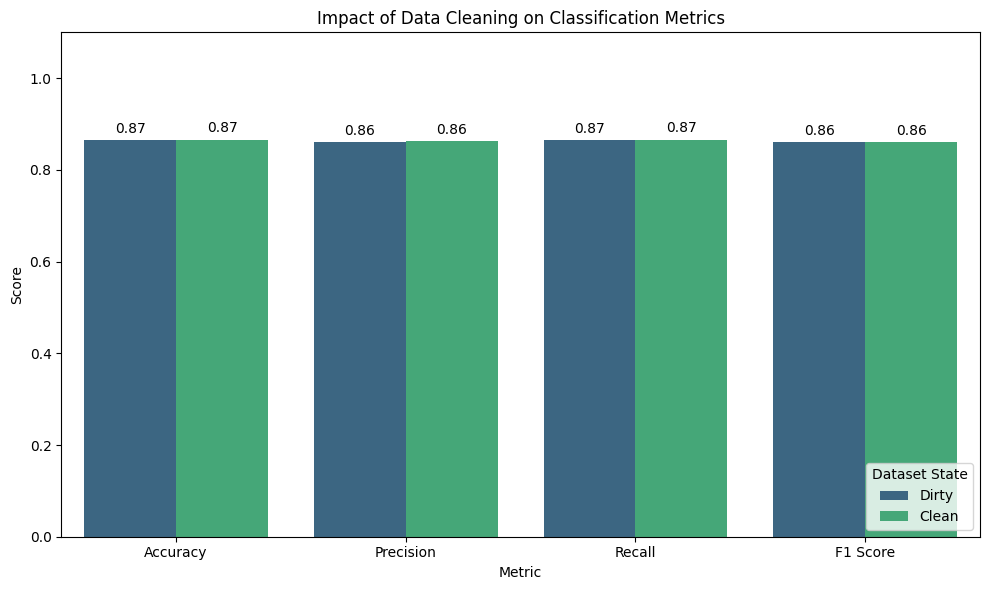

Final Conclusion:
The cleaning pipeline improved the F1 Score (weighted) from 86.02% to 86.10%.


In [57]:
# --- IMPACT COMPARISON (METRICS ONLY) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create Comparison Dataframe
# We structure the data to make it easy to plot grouped bars
metrics_data = {
    'Metric': ['Accuracy', 'Accuracy',
               'Precision', 'Precision',
               'Recall', 'Recall',
               'F1 Score', 'F1 Score'],
    'State': ['Dirty', 'Clean',
              'Dirty', 'Clean',
              'Dirty', 'Clean',
              'Dirty', 'Clean'],
    'Score': [dirty_acc, clean_acc,
              dirty_prec, clean_prec,
              dirty_rec, clean_rec,
              dirty_f1, clean_f1]
}

results_df = pd.DataFrame(metrics_data)

# 2. Setup the Figure
plt.figure(figsize=(10, 6))

# 3. Plot Grouped Bar Chart
ax = sns.barplot(x='Metric', y='Score', hue='State', data=results_df, palette='viridis')

plt.title('Impact of Data Cleaning on Classification Metrics')
plt.ylim(0, 1.1) # Set limit slightly above 1 to fit text
plt.ylabel('Score')
plt.legend(title='Dataset State', loc='lower right')

# Add text labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

# 4. Print Summary
print("Final Conclusion:")
print(f"The cleaning pipeline improved the F1 Score (weighted) from {dirty_f1:.2%} to {clean_f1:.2%}.")